In [22]:
import numpy as np
import pandas as pd
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score


In [23]:

filename = "data/preprocessed_data2.xlsx"  # removed an outlier row which had value 2861 for k

df = pd.read_excel(filename)
df.columns = df.columns.astype(str)
print(df.head())
for i, col in enumerate(df.columns):
    print(i, col)
spectral_data = df.iloc[:, list(range(1,434))+[440]]
output_variable = df.iloc[:, 438:439]

   NaN  349.866666666667    354.95     359.3    365.15     369.5   375.325  \
0    1          0.154092  0.145253  0.132048  0.120393  0.117365  0.116590   
1    2          0.220826  0.194554  0.188793  0.163819  0.154851  0.156193   
2    3          0.223714  0.208908  0.189445  0.175717  0.172087  0.169890   
3    4          0.229010  0.193448  0.174742  0.176795  0.164635  0.163062   
4    5          0.274307  0.245903  0.231115  0.219347  0.206839  0.206962   

      379.7   384.075     389.9  ...    2500.3    2504.5  2507.26666666667  \
0  0.117083  0.118773  0.119548  ...  0.906052  0.904784          0.906521   
1  0.157240  0.156618  0.158353  ...  0.893384  0.894562          0.894388   
2  0.174863  0.175320  0.178920  ...  0.906650  0.907749          0.907098   
3  0.168613  0.165629  0.169800  ...  0.904190  0.902394          0.902522   
4  0.207579  0.208688  0.213001  ...  0.893572  0.893982          0.896283   

      EC  NO3-N_Wet  OM_Wet  P_Wet  K_Wet   P_XRF   K_XRF  
0 

In [24]:
spectral_data.head()
output_variable.head()

,K_Wet
0,728
1,277
2,329
3,525
4,229


In [25]:
print(spectral_data.shape)
print(output_variable.shape)

(109, 434)
(109, 1)


In [26]:
output_variable.describe()

,K_Wet
count,109.000000
mean,387.614679
std,211.648770
min,64.000000
25%,230.000000
50%,339.000000
75%,534.000000
max,1006.000000


Text(0.5, 1.0, 'Output K Distribution')

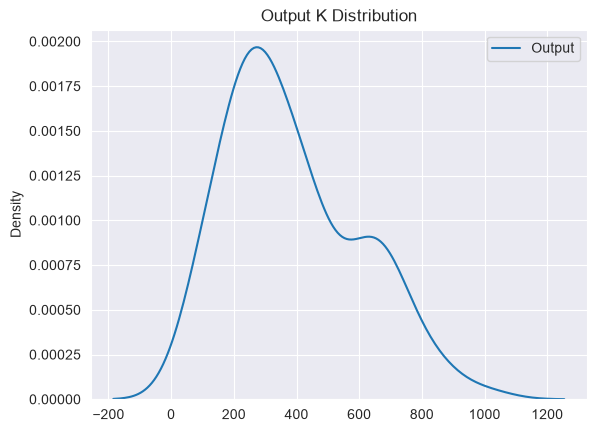

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.kdeplot(output_variable, label='Output')
plt.legend()
plt.title("Output K Distribution")

In [28]:
# skip, no need to apply filter
# from scipy.signal import savgol_filter
# #
# X = savgol_filter(spectral_data.values, window_length=11, polyorder=2, deriv=1, axis=1)
y = output_variable.values.ravel()

In [12]:
# skip
# y_log = np.log1p(output_variable.values.ravel())
# sns.kdeplot(y_log)

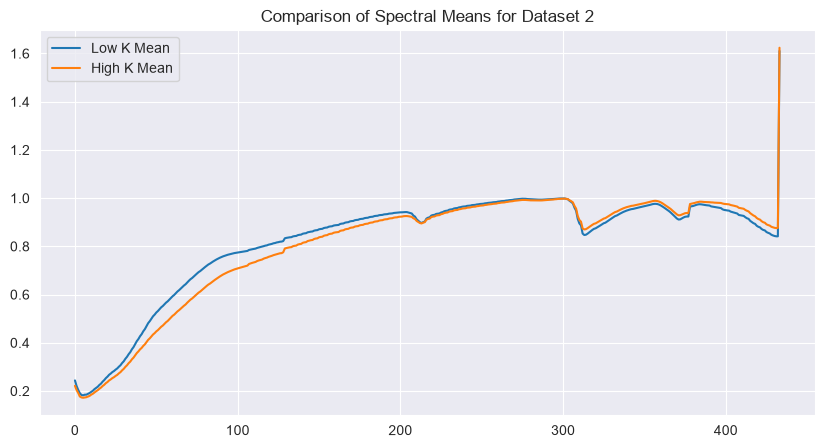

In [29]:

X_train_arr = np.array(spectral_data)

median_val = np.median(y)
low_n = X_train_arr[y <= median_val]
high_n = X_train_arr[y > median_val]

plt.figure(figsize=(10, 5))
plt.plot(np.mean(low_n, axis=0), label='Low K Mean')
plt.plot(np.mean(high_n, axis=0), label='High K Mean')
plt.legend()
plt.title("Comparison of Spectral Means for Dataset 2")
plt.show()

In [36]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.ensemble import RandomForestRegressor

pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    ('pca', PCA(n_components=10)),
    ('regressor', Ridge(alpha=1.0))
])

# pipeline = Pipeline([
#     ('scaler', StandardScaler()),
#     ('feat_select', SelectKBest(score_func=f_regression, k=50)),
#     ('rf', RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42))
# ])

# pipeline = Pipeline([
#     ('scaler', MinMaxScaler()),
#     ('pls', PLSRegression(n_components=10))
# ])



from sklearn.base import BaseEstimator, TransformerMixin

# Standard Normal Variate
class SNV(BaseEstimator, TransformerMixin):
    def fit(self, X, y):
        return self
    def transform(self, X):
        X_arr = np.array(X)
        return (X_arr - np.mean(X_arr, axis=1, keepdims=True)) / np.std(X_arr, axis=1, keepdims=True)

#
# pipeline = Pipeline([
#     ('snv', SNV()),
#     ('pls', PLSRegression(n_components=10))
# ])

In [37]:
from sklearn.model_selection import LeaveOneOut, cross_val_predict

cv = LeaveOneOut()
y_pred = cross_val_predict(pipeline, spectral_data, y, cv=cv)

In [38]:
r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

print(f"LOOCV R2 Score: {r2:.4f}")
print(f"LOOCV RMSE: {rmse:.4f}")

LOOCV R2 Score: 0.5326
LOOCV RMSE: 144.0242


Train/Test split

In [39]:
X_train, X_test, y_train, y_test = train_test_split(spectral_data, y, test_size=0.2, random_state=42)

In [40]:
X_train

,349.866666666667,354.95,359.3,365.15,369.5,375.325,379.7,384.075,389.9,394.275,...,2467.13333333333,2474.96666666667,2479.2,2482.06666666667,2489.8,2494,2500.3,2504.5,2507.26666666667,K_XRF
65,0.239411,0.216169,0.194070,0.188055,0.178299,0.172879,0.176096,0.175677,0.178964,0.183125,...,0.862345,0.855211,0.851761,0.848917,0.842530,0.840525,0.839080,0.840758,0.838240,1.7016
26,0.206888,0.185719,0.179242,0.163760,0.160253,0.158420,0.159874,0.158389,0.161801,0.164708,...,0.918504,0.915176,0.910585,0.908225,0.903971,0.901022,0.902285,0.900769,0.901948,1.6584
22,0.196715,0.202006,0.191002,0.167273,0.171493,0.164124,0.164546,0.167597,0.167695,0.168733,...,0.851393,0.843429,0.843169,0.838798,0.832652,0.829882,0.822697,0.822437,0.822567,1.5455
31,0.229963,0.205075,0.180498,0.172705,0.160683,0.161949,0.164780,0.163015,0.164313,0.170374,...,0.910706,0.907020,0.901736,0.899871,0.896230,0.891701,0.890014,0.889570,0.890058,1.6647
47,0.267072,0.234417,0.230043,0.212151,0.198117,0.203797,0.204435,0.203493,0.209690,0.210693,...,0.882139,0.876428,0.872215,0.871972,0.868287,0.866748,0.862697,0.862738,0.862778,1.7526
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,0.169979,0.159260,0.159609,0.136548,0.133469,0.139208,0.135288,0.134833,0.139033,0.137423,...,0.820689,0.811543,0.808324,0.804871,0.801092,0.798199,0.791760,0.791713,0.789287,1.5672
14,0.222353,0.197319,0.182194,0.171583,0.162161,0.161795,0.165515,0.165088,0.165484,0.171034,...,0.929623,0.924419,0.923443,0.922345,0.916206,0.914539,0.913929,0.911490,0.915108,1.6911
92,0.252655,0.242317,0.226494,0.207394,0.206231,0.202601,0.201403,0.205843,0.209050,0.211235,...,0.938305,0.932525,0.930975,0.928249,0.923926,0.922235,0.922705,0.921154,0.920872,1.2565
51,0.224164,0.221536,0.191704,0.183394,0.178138,0.173911,0.178848,0.180340,0.184317,0.188330,...,0.868528,0.859625,0.861520,0.854796,0.847693,0.841679,0.842200,0.841726,0.840116,1.8020


In [41]:

pipeline = Pipeline([
    ('snv', SNV()),
    ('pls', PLSRegression(n_components=10))
])

In [47]:


pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    ('pca', PCA(n_components=10)),
    ('regressor', Ridge(alpha=1.0))
])

# pipeline = Pipeline([
#     ('scaler', MinMaxScaler()),
#     ('regressor', PLSRegression(n_components=2))
# ])

In [45]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'regressor__n_components': [5, 10, 15, 20, 25]
}

grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='r2')
grid.fit(X_train, y_train)

print(f"Best R2: {grid.best_score_}")

Best R2: 0.6812608136720943


In [48]:
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print(f"R2 Score: {r2_score(y_test, y_pred)}")
print(f"RMSE: {rmse:.4f}")

R2 Score: 0.6694164321052534
RMSE: 144.0242


Feature selection using lasso

In [49]:
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestRegressor


selector = SelectFromModel(estimator=Lasso(alpha=0.4)).fit(X_train, y_train)
X_train_selected = selector.transform(X_train)
X_test_selected = selector.transform(X_test)


C:\Users\berge\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.620525e+02, tolerance: 3.679e+02
  model = cd_fast.enet_coordinate_descent(


In [50]:
X_train_selected

array([[0.17829918, 0.17609623, 0.42723267, 0.49625848, 0.50758794,
        0.51821806, 0.59717463, 0.91181201, 0.90994708, 0.90309346],
       [0.16025276, 0.15987362, 0.34622433, 0.3928278 , 0.40056872,
        0.40837283, 0.47797788, 0.96391785, 0.96139021, 0.95587151],
       [0.17149257, 0.16454587, 0.33165617, 0.37440758, 0.38180874,
        0.38882036, 0.45575537, 0.91237638, 0.91168387, 0.90207535],
       [0.16068336, 0.16477954, 0.38044492, 0.43615958, 0.44541761,
        0.45447582, 0.53130412, 0.95666267, 0.95306603, 0.9497358 ],
       [0.19811665, 0.20443499, 0.43751519, 0.49383354, 0.50334143,
        0.51251519, 0.58353584, 0.92498987, 0.9218307 , 0.91551235],
       [0.17560761, 0.17686689, 0.44780254, 0.51788188, 0.52908954,
        0.53982496, 0.61799521, 0.92973177, 0.92813667, 0.91974143],
       [0.18710279, 0.17795102, 0.39117448, 0.43988857, 0.44837302,
        0.45615838, 0.5238751 , 0.97216338, 0.96843488, 0.96330819],
       [0.18235722, 0.17995635, 0.4232448

In [51]:

pls = PLSRegression(n_components=5)
pls.fit(X_train_selected, y_train)

# 5. Prediction & Evaluation
y_pred = pls.predict(X_test_selected)
print(f"R2 Score: {r2_score(y_test, y_pred)}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}")

R2 Score: 0.5954736769388063
RMSE: 145.34015093004177


Feature Importance from RF

In [52]:

# 2. Using Random Forest importance
rf = RandomForestRegressor().fit(X_train, y_train)
selector_rf = SelectFromModel(rf, threshold='median').fit(X_train, y_train)
X_train_selected_rf = selector_rf.transform(X_train)
X_test_selected_rf = selector_rf.transform(X_test)

pls = PLSRegression(n_components=6)
pls.fit(X_train_selected_rf, y_train)

y_pred = pls.predict(X_test_selected_rf)
print(f"R2 Score: {r2_score(y_test, y_pred)}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}")

R2 Score: 0.7324005060132618
RMSE: 118.21017419211225


In [43]:
X_train_selected_rf

array([[0.23941068, 0.21616896, 0.18805511, ..., 0.84891717, 0.84252978,
        0.84052498],
       [0.20688784, 0.1857188 , 0.16375987, ..., 0.90822538, 0.90397051,
        0.90102159],
       [0.19671493, 0.2020061 , 0.16727261, ..., 0.83879764, 0.83265165,
        0.82988162],
       ...,
       [0.48434749, 0.4459866 , 0.42210428, ..., 0.97060262, 0.96796126,
        0.96654275],
       [0.22416365, 0.22153562, 0.18339371, ..., 0.85479556, 0.84769278,
        0.8416791 ],
       [0.1846483 , 0.15040606, 0.13295202, ..., 0.88477492, 0.87936078,
        0.87647906]], shape=(88, 217))

In [53]:
mask = selector_rf.get_support()

selected_columns = X_train.columns[mask]

# 3. View the results
print(f"Number of features selected: {len(selected_columns)}")
print("Selected columns (wavelengths):")
print(selected_columns)

Number of features selected: 217
Selected columns (wavelengths):
Index(['349.866666666667', '354.95', '359.3', '365.15', '379.7', '384.075',
       '434.95', '469.575', '534.8', '540.4',
       ...
       '2429.7', '2436.96666666667', '2467.13333333333', '2474.96666666667',
       '2479.2', '2482.06666666667', '2494', '2500.3', '2507.26666666667',
       'K_XRF'],
      dtype='str', length=217)


RF with GridSearchCV

In [54]:
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

# Define a pipeline
pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    # ('pca', PCA(n_components=10)),
    ('model', RandomForestRegressor(random_state=42))
])

# Define parameters to tune
param_grid = {
    'model__n_estimators': [50, 100, 200],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5, 10]
}

# Use 5-fold Cross-Validation
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Grid search
grid = GridSearchCV(pipeline, param_grid, cv=cv, scoring='r2')
grid.fit(X_train, y_train)

print(f"Best parameters: {grid.best_params_}")
print(f"Best CV RMSE: {-grid.best_score_}")

Best parameters: {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Best CV RMSE: -0.41245799299476077


In [48]:
best_rf = grid.best_estimator_

In [49]:
y_test_pred = best_rf.predict(X_test)

print("Test R²:", r2_score(y_test, y_test_pred))
print("Test MSE:", mean_squared_error(y_test, y_test_pred))

Test R²: 0.6287625900302873
Test MSE: 19066.109846732532
